# ════════════════════════════════════════════════════════════════════════
# Dynamic Portfolio Optimization Under Capital Constraints
# ════════════════════════════════════════════════════════════════════════

**Author:** Nadav Gordon-Bar
**Date:** March 2026

### Executive Summary & Core Assumptions
This research notebook details the architecture of a dynamic, out-of-sample portfolio allocation engine for a multi-strategy quantitative fund.

Unlike theoretical models that assume free and unlimited capital (where total absolute return can be maximized by blindly activating all positive-EV signals), realistic institutional trading environments operate under **Strict Capital Constraints and Margin Limits**.

**Our Domain Assumptions (The "Fixed Pie" Model):**
1. **Constrained Capital (1/N Allocation):** We deploy a fixed pool of capital. Selecting a strategy means allocating a slice of the pie (using mathematical `MEAN` across active portfolio weights).
2. **Concentration Limits (Fixed K):** Due to prime broker margin requirements and operational overhead, the portfolio is strictly limited to $K=5$ active strategies at any given time.
3. **The Opportunity Cost of Failure (Cash Drag):** If a selected strategy stops trading, its allocated capital sits idle in cash (generating 0% return) until the next rebalance period.

### The Research Objective
Given these constraints, maximizing absolute PnL is mathematically impossible without taking on unacceptable concentration risk. Therefore, our objective is to maximize **Capital Efficiency (Portfolio-Level Sharpe Ratio)** while surviving non-stationary market regimes, alpha decay, and hidden "Penny Picker" traps.

We will progress from establishing the theoretical upper bounds of the market to building a fully autonomous, Correlation-Aware Walk-Forward Engine.

#### ════════════════════════════════════════════════════════════════════════
### Part 0: Setup, Market Simulation & Universe Characterization
#### ════════════════════════════════════════════════════════════════════════

To rigorously test our allocation engine, we utilize a synthetic multi-strategy universe calibrated to empirical market micro-structure.

The environment explicitly models phenomena that destroy naive portfolios:
* **Alpha Decay:** Strategies systematically lose their edge over time.
* **Regime-Dependent Correlations:** Diversification vanishes during market crashes.
* **The "Penny Picker" Trap:** High-Sharpe strategies that generate negligible absolute returns per contract, masking severe tail risks.

In [18]:
# ==============================================================================
# CELL 0.1 | Architecture Imports & Configuration
# ==============================================================================

from __future__ import annotations
import os
from pathlib import Path
from typing import List, Optional
from io import StringIO
import random
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Data Manipulation & Visualization
from IPython.display import display
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


class Config:
    """
    Centralized configuration.
    """
    # 1. Path Management
    BASE_DIR = Path.cwd()
    DATA_DIR = BASE_DIR / "data"
    DATA_FILE = DATA_DIR / "data.txt"

    # 2. Reproducibility
    SEED = 42
    MOCK = True
    SYN_DF = 'V1'  # {V1, V2}


os.environ["PYTHONHASHSEED"] = str(Config.SEED)   # best-effort in notebook
random.seed(Config.SEED)
np.random.seed(Config.SEED)                      # legacy/global RNG (E2E)

# --- Frameworks Configuration & Styling ---
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
%matplotlib inline
plt.rcParams['figure.figsize'] = (18, 10)
matplotlib.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)

print("Libraries Loaded Successfully.")

Libraries Loaded Successfully.


In [11]:
# ==============================================================================
# CELL 0.2 | GLOBAL MASTER FUNCTIONS
# ==============================================================================

def to_wide_pnl(df_to_wide: pd.DataFrame) -> pd.DataFrame:
    """Long → wide: months × strategies (PnL). NaN = inactive."""
    return df_to_wide.pivot_table(index="month", columns="strategy", values="pnl", aggfunc="first")

def to_wide_contracts(df_to_wide: pd.DataFrame) -> pd.DataFrame:
    """Long → wide: months × strategies (contracts)."""
    return df_to_wide.pivot_table(index="month", columns="strategy", values="contracts", aggfunc="first")

def compute_annualized_sharpe(df_group: pd.DataFrame, pnl_col: str ='pnl') -> float:
    """Computes the annualized Sharpe Ratio. Assumes 0% risk-free rate."""
    if len(df_group) < 2 or df_group[pnl_col].std() == 0:
        return 0.0
    return (df_group[pnl_col].mean() / df_group[pnl_col].std()) * np.sqrt(12)

def compute_ppc(df_group: pd.DataFrame, pnl_col: str ='pnl', contracts_col: str ='contracts') -> float:
    """
    Computes Profit Per Contract (PPC).
    Crucial for understanding scalability and resilience to transaction costs.
    """
    total_pnl = df_group[pnl_col].sum()
    total_contracts = df_group[contracts_col].sum()
    if total_contracts == 0:
        return 0.0
    return total_pnl / total_contracts

def evaluate_portfolio_metric(
    pnl_df: pd.DataFrame,
    contracts_df: Optional[pd.DataFrame] = None,
    weights: Optional[np.ndarray] = None,
    objective: str = 'sharpe',
    alpha: float = 0.5,
    is_selection: bool = False
) -> float:
    """Generic evaluator for a portfolio given an objective metric (UNDER CAPITAL CONSTRAINTS)."""
    if is_selection:
        pnl_df = pnl_df.dropna()
        if contracts_df is not None:
            contracts_df = contracts_df.loc[pnl_df.index]
        if len(pnl_df) < 2:
            return -np.inf

    if weights is None:
        # CONSTRAINED CAPITAL: We share the pie (MEAN)
        port_pnl = pnl_df.fillna(0).mean(axis=1)
        port_contracts = contracts_df.fillna(0).mean(axis=1) if contracts_df is not None else None
    else:
        # Weights array inherently sums to 1.0 (Markowitz allocation)
        port_pnl = pnl_df.fillna(0).dot(weights)
        port_contracts = contracts_df.fillna(0).dot(weights) if contracts_df is not None else None

    if port_pnl.std() == 0: return 0.0
    sharpe = (port_pnl.mean() / port_pnl.std()) * np.sqrt(12)

    if objective == 'sharpe':
        return sharpe
    elif objective == 'joint':
        ppc = port_pnl.sum() / port_contracts.sum() if (port_contracts is not None and port_contracts.sum() > 0) else 0
        return sharpe * np.log1p(alpha * max(0, ppc))
    elif objective == 'pnl':
        return port_pnl.sum()

    return 0.0

def select_top_k_greedy_master(
    pnl_df: pd.DataFrame,
    contracts_df: Optional[pd.DataFrame] = None,
    metrics_df: Optional[pd.DataFrame] = None,
    objective: str = 'sharpe',
    alpha: float = 0.5,
    k: int = 5,
    is_selection: bool = False
) -> List[str]:
    """
    Greedy Marginal Selection Algorithm for Fixed-K Portfolios.
    Evaluates correlation and contribution iteratively to build a robust portfolio subset.
    """
    valid = metrics_df[metrics_df['Sharpe'] > 0].copy()

    if objective == 'joint':
        valid['Score'] = valid['Sharpe'] * np.log1p(alpha * valid['PPC'].clip(lower=0))
    else:
        valid['Score'] = valid['Sharpe']

    valid = valid.sort_values(by='Score', ascending=False)
    if valid.empty: return []

    best_initial = valid.iloc[0]['strategy']
    selected = [best_initial]
    candidates = valid['strategy'].tolist()[1:]

    # Add K-1 remaining strategies
    for _ in range(1, k):
        best_cand, best_score = None, -np.inf

        for cand in candidates:
            test_port = selected + [cand]
            score = evaluate_portfolio_metric(
                pnl_df[test_port],
                contracts_df[test_port] if contracts_df is not None else None,
                objective=objective, alpha=alpha, is_selection=is_selection
            )
            if score > best_score:
                best_score, best_cand = score, cand

        if best_cand:
            selected.append(best_cand)
            candidates.remove(best_cand)
        else:
            break

    return selected

def get_optimal_weights_master(
    pnl_df: pd.DataFrame,
    contracts_df: Optional[pd.DataFrame] = None,
    objective: str = 'sharpe',
    alpha: float = 0.5
) -> np.ndarray:
    """Generic Markowitz Optimizer with Concentration Limits."""
    n_assets = pnl_df.shape[1]

    def negative_objective(weights):
        return -evaluate_portfolio_metric(pnl_df, contracts_df, weights, objective, alpha)

    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
    bounds = tuple((0.05, 0.40) for _ in range(n_assets))
    init_guess = np.ones(n_assets) / n_assets

    result = minimize(negative_objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x if result.success else init_guess

In [12]:
# ==============================================================================
# CELL 0.3 | DATA INGESTION
# ==============================================================================
# --- Execution ---
if Config.SYN_DF == 'V1':
    from synthetic_data import generate_living_quant_universe
    df, _ = generate_living_quant_universe(seed=75)
    # Prepare wide-format matrices
    df_pnl = to_wide_pnl(df)
    df_contracts = to_wide_contracts(df)
else:
    if Config.SYN_DF =='V2':
        from synthetic_data import generate_realistic_quant_data
        df, df_pnl, df_contracts = generate_realistic_quant_data()
        print(f"Realistic Data Generated. Regimes embedded. Survivorship bias simulated.")
    else:
        raise NotImplementedError("Currently, only V1 and V2 are supported")

# Calculate in-sample metrics for our synthetic universe
metrics_df = df.groupby('strategy').apply(
    lambda x: pd.Series({
        'Sharpe': compute_annualized_sharpe(x),
        'PPC': compute_ppc(x)
    })
).reset_index()

print(metrics_df.sort_values(by='Sharpe', ascending=False).head(15))

     strategy    Sharpe       PPC
45  strat_045  2.448468  0.182805
43  strat_043  1.988120  0.183976
37  strat_037  1.974184  0.001155
17  strat_017  1.930466  0.161395
7   strat_007  1.782984  0.000902
1   strat_001  1.439996  0.255825
25  strat_025  1.371242  0.065399
40  strat_040  1.291456  0.000530
38  strat_038  1.150330  0.082485
8   strat_008  1.066896  0.043375
35  strat_035  0.923074  0.035956
0   strat_000  0.867973  0.078826
46  strat_046  0.772825  0.030192
3   strat_003  0.713804  0.092087
5   strat_005  0.642547  0.064789


#### ════════════════════════════════════════════════════════════════════════
### Part 1: Exploratory Data Analysis (Universe Characterization)
#### ════════════════════════════════════════════════════════════════════════

As a quantitative research desk, before deploying constrained capital, we must deeply understand the lifecycle, decay rates, and risk-return profiles of our available strategy universe.

This Exploratory Data Analysis (EDA) highlights three critical market realities that our allocation engine must overcome:

1. **Survivorship Bias & Alpha Decay:** Strategies do not live forever. The lifespan distributions and the Gantt chart reveal that trading edges systematically decay. A static "Buy & Hold" portfolio will inevitably suffer from severe "Cash Drag" as its constituents die out.
2. **The Strategy Landscape (Sharpe vs. PPC):** The scatter plot exposes the "Penny Picker" trap-strategies with mathematically inflated Sharpe ratios but microscopic Profit Per Contract (PPC). In a capital-constrained environment where margin is limited, allocating our "fixed pie" to these strategies is a severe misallocation of resources.
3. **Regime Non-Stationarity:** The cumulative PnL curves demonstrate structural breaks. Strategies that dominate in early regimes can suffer catastrophic drawdowns in later ones.

Let's visualize the synthetic universe.

--- DATASET OVERVIEW ---
Total Duration: 119 Months
Unique Strategies: 50
Average active strategies per month: 36
Average strategy lifetime: 86 months
Global Mean Sharpe Ratio: 0.27
Global Mean PPC: $0.02


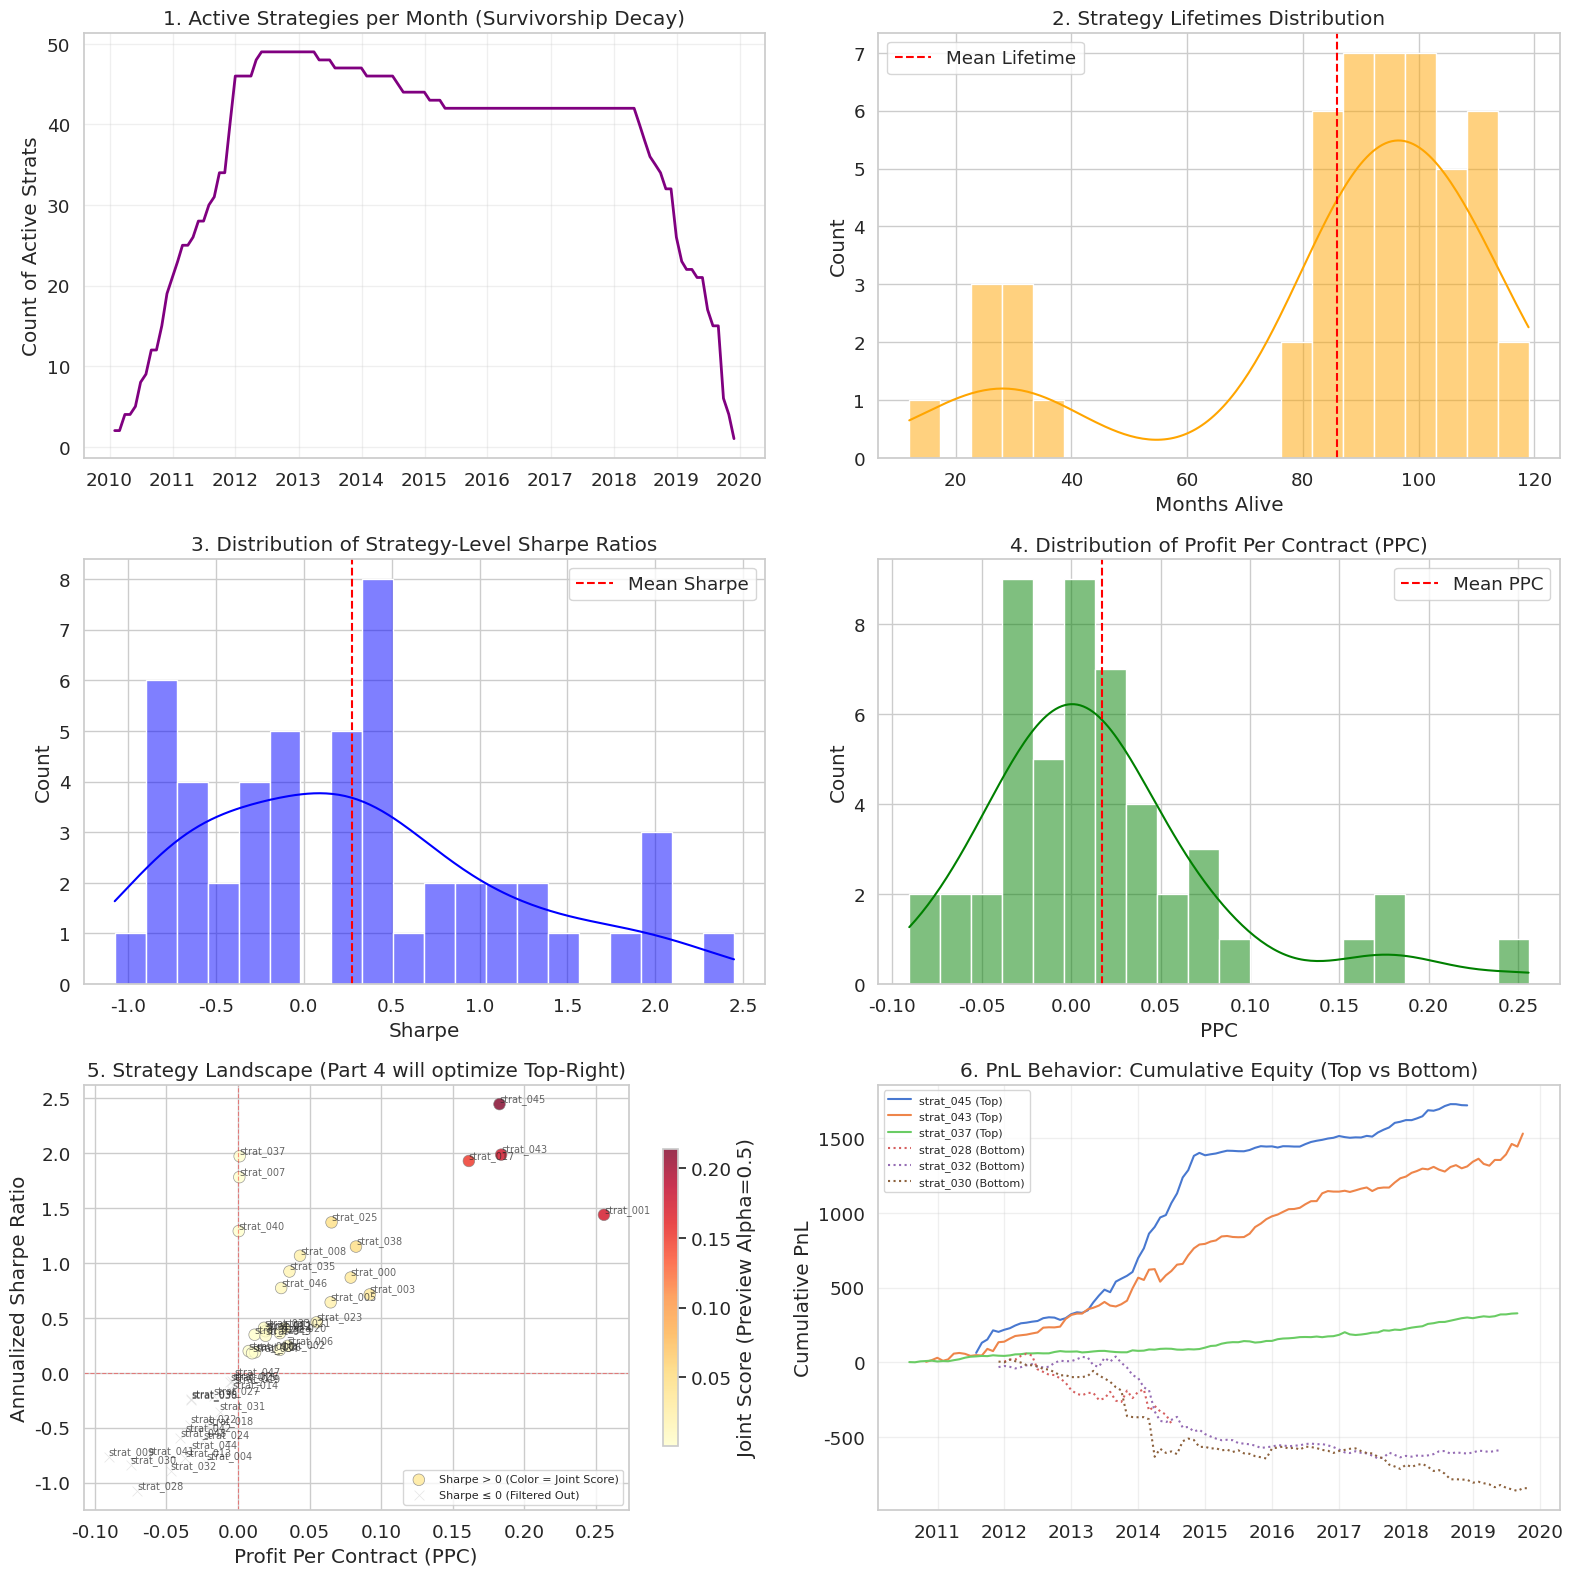

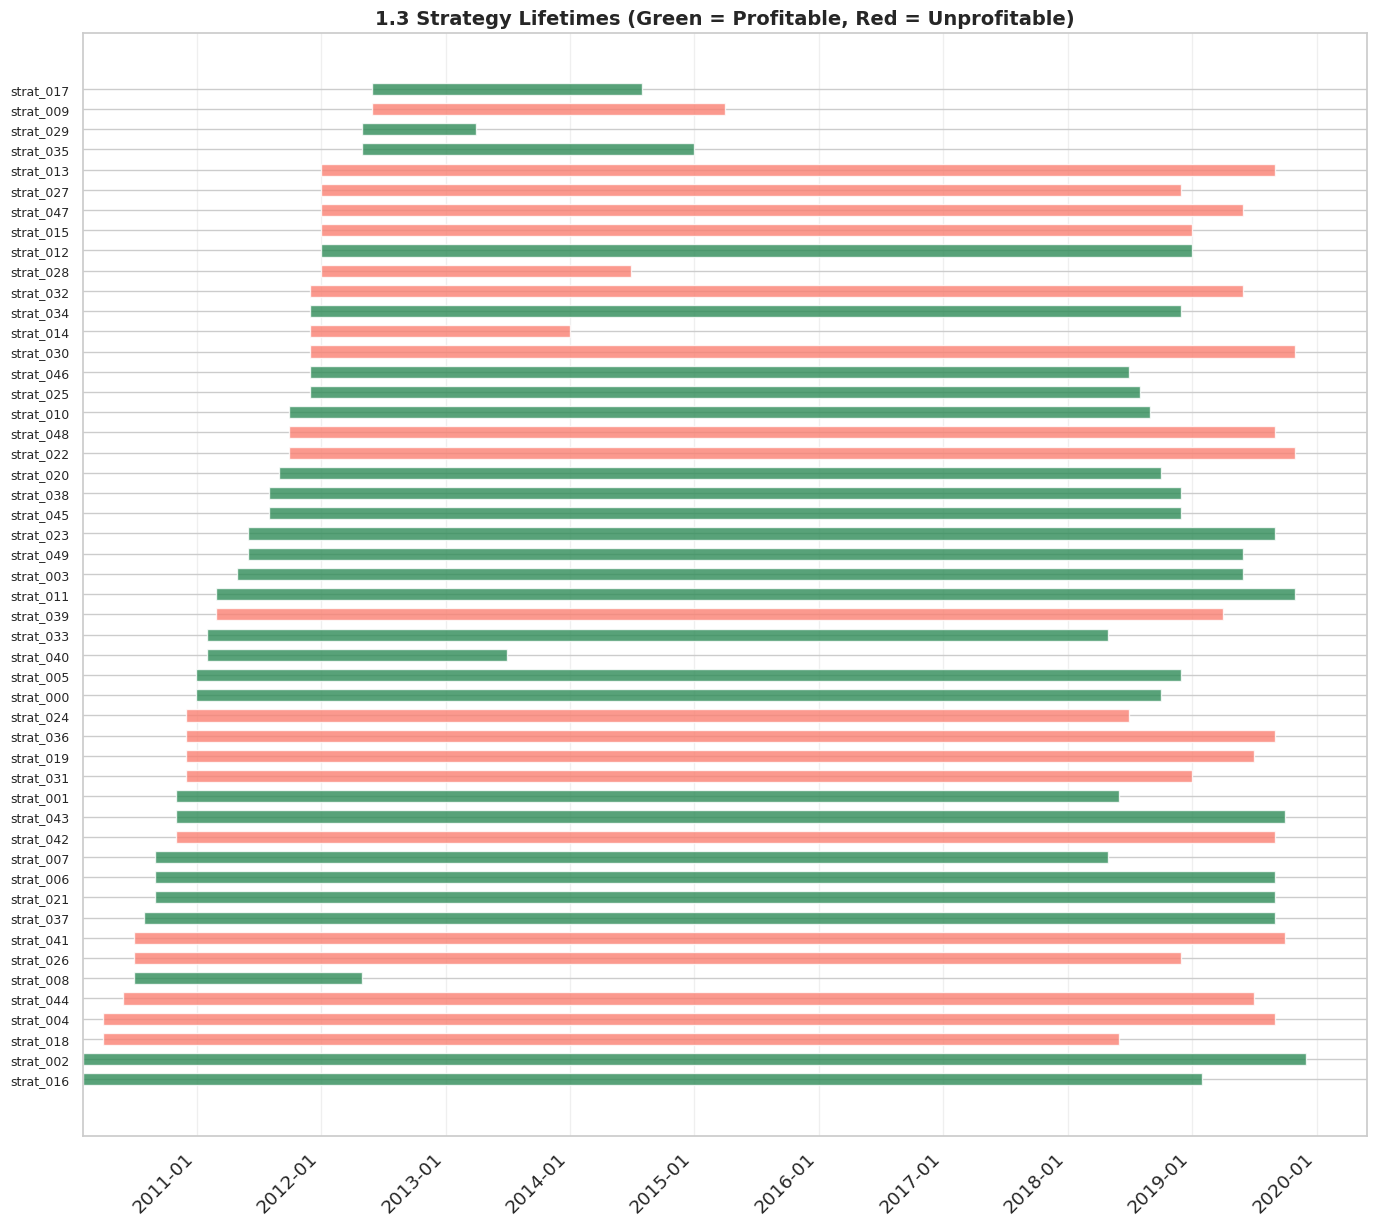

In [13]:
# --- 1.1 Summary Statistics & Dimensions ---
n_months = df_pnl.shape[0]
n_strategies = df_pnl.shape[1]

# Count active strategies per month (non-NaN)
active_strats_per_month = df_pnl.notna().sum(axis=1)

# Calculate strategy lifetimes (how many months each strategy existed before turning NaN)
strategy_lifetimes = df_pnl.notna().sum(axis=0)

print(f"--- DATASET OVERVIEW ---")
print(f"Total Duration: {n_months} Months")
print(f"Unique Strategies: {n_strategies}")
print(f"Average active strategies per month: {active_strats_per_month.mean():.0f}")
print(f"Average strategy lifetime: {strategy_lifetimes.mean():.0f} months")
print(f"Global Mean Sharpe Ratio: {metrics_df['Sharpe'].mean():.2f}")
print(f"Global Mean PPC: ${metrics_df['PPC'].mean():.2f}")

# --- 1.2 Comprehensive EDA Visualizations ---
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

# Plot 1: Active Strategies Over Time (Survivorship Bias)
axes[0].plot(active_strats_per_month.index, active_strats_per_month.values, color='purple', linewidth=2)
axes[0].set_title("1. Active Strategies per Month (Survivorship Decay)")
axes[0].set_ylabel("Count of Active Strats")
axes[0].grid(True, alpha=0.3)

# Plot 2: Strategy Lifetimes (Appearance/Disappearance behavior)
sns.histplot(strategy_lifetimes, bins=20, ax=axes[1], color='orange', kde=True)
axes[1].axvline(strategy_lifetimes.mean(), color='red', linestyle='--', label='Mean Lifetime')
axes[1].set_title("2. Strategy Lifetimes Distribution")
axes[1].set_xlabel("Months Alive")
axes[1].legend()

# Plot 3: Sharpe Ratio Distribution
sns.histplot(metrics_df['Sharpe'], bins=20, ax=axes[2], color='blue', kde=True)
axes[2].axvline(metrics_df['Sharpe'].mean(), color='red', linestyle='--', label='Mean Sharpe')
axes[2].set_title("3. Distribution of Strategy-Level Sharpe Ratios")
axes[2].legend()

# Plot 4: PPC Distribution
sns.histplot(metrics_df['PPC'], bins=20, ax=axes[3], color='green', kde=True)
axes[3].axvline(metrics_df['PPC'].mean(), color='red', linestyle='--', label='Mean PPC')
axes[3].set_title("4. Distribution of Profit Per Contract (PPC)")
axes[3].legend()

# Plot 5: The Strategy Landscape (Sharpe vs PPC)
# Pre-calculate a "Preview" Joint Score just for the color map
has_pos_sharpe = metrics_df['Sharpe'] > 0
preview_alpha = 0.5
metrics_df['Preview_Score'] = np.where(has_pos_sharpe,
                                       metrics_df['Sharpe'] * np.log1p(preview_alpha * metrics_df['PPC'].clip(lower=0)),
                                       np.nan)

pos_data = metrics_df[has_pos_sharpe]
sc = axes[4].scatter(pos_data['PPC'], pos_data['Sharpe'], c=pos_data['Preview_Score'],
                     cmap="YlOrRd", s=70, alpha=0.8, edgecolors="gray", linewidth=0.5,
                     label="Sharpe > 0 (Color = Joint Score)")

neg_data = metrics_df[~has_pos_sharpe]
if not neg_data.empty:
    axes[4].scatter(neg_data['PPC'], neg_data['Sharpe'], c="lightgray", s=50, alpha=0.6,
                    edgecolors="gray", linewidth=0.5, marker="x",
                    label="Sharpe ≤ 0 (Filtered Out)")

# Annotate strategy names (cleaned up to save space)
for _, row in metrics_df.iterrows():
    clean_name = row['strategy'].replace('Strat_', '')
    axes[4].annotate(clean_name, (row['PPC'], row['Sharpe']), fontsize=7, alpha=0.7, ha="left", va="bottom")

axes[4].axhline(0, color="red", lw=0.8, ls="--", alpha=0.4)
axes[4].axvline(0, color="red", lw=0.8, ls="--", alpha=0.4)
axes[4].set_xlabel("Profit Per Contract (PPC)")
axes[4].set_ylabel("Annualized Sharpe Ratio")
axes[4].set_title("5. Strategy Landscape (Part 4 will optimize Top-Right)")
axes[4].legend(fontsize=8, loc="lower right")
fig.colorbar(sc, ax=axes[4], label=f"Joint Score (Preview Alpha={preview_alpha})", shrink=0.7)

# Plot 6: PnL Behavior Over Time (Top 3 vs Bottom 3)
top3 = metrics_df.nlargest(3, 'Sharpe')['strategy']
bottom3 = metrics_df.nsmallest(3, 'Sharpe')['strategy']
for strat in top3:
    axes[5].plot(df_pnl.index, df_pnl[strat].cumsum(), label=f"{strat} (Top)", linestyle='-')
for strat in bottom3:
    axes[5].plot(df_pnl.index, df_pnl[strat].cumsum(), label=f"{strat} (Bottom)", linestyle=':')
axes[5].set_title("6. PnL Behavior: Cumulative Equity (Top vs Bottom)")
axes[5].set_ylabel("Cumulative PnL")
axes[5].legend(fontsize=8)
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 1.3 Strategy Lifetimes (Clean Gantt Chart) ---
# Find first and last valid (non-NaN) months for each strategy
first_valid = df_pnl.apply(lambda col: col.first_valid_index())
last_valid = df_pnl.apply(lambda col: col.last_valid_index())
lifetime_df = pd.DataFrame({'first': first_valid, 'last': last_valid}).dropna().sort_values('first')

fig, ax = plt.subplots(figsize=(14, max(6, n_strategies * 0.25)))

for i, (strat, row) in enumerate(lifetime_df.iterrows()):
    start = mdates.date2num(row['first'])
    end = mdates.date2num(row['last'])

    # Color by profitability (Sharpe > 0)
    strat_sharpe = metrics_df.loc[metrics_df['strategy'] == strat, 'Sharpe'].values[0]
    color = "seagreen" if strat_sharpe > 0 else "salmon"

    ax.barh(i, end - start, left=start, height=0.6, color=color, alpha=0.8)

ax.set_yticks(range(len(lifetime_df)))
ax.set_yticklabels(lifetime_df.index, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.YearLocator())
fig.autofmt_xdate(rotation=45)

ax.set_title("1.3 Strategy Lifetimes (Green = Profitable, Red = Unprofitable)", fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### ════════════════════════════════════════════════════════════════════════
### Part 2: Oracle Solution (The Concentration Ceiling)
#### ════════════════════════════════════════════════════════════════════════
If we possessed perfect foresight but were still constrained to holding only $K=5$ strategies per month, what is the maximum absolute return we could extract from this market?

By forcing the Oracle to adhere to the $K=5$ constraint and allocating capital symmetrically (1/N), we define the true baseline for capital efficiency.

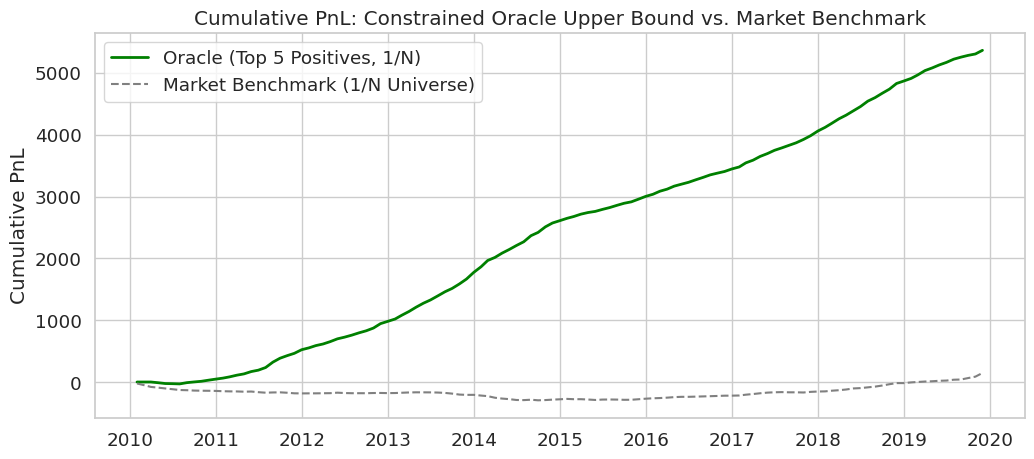

Constrained Oracle Total PnL: $5,365
Market Benchmark Total PnL: $146


In [14]:
# The Constrained Oracle: Perfect foresight, but limited to 5 strategies (1/N allocation).
oracle_pnl = df_pnl.apply(lambda row: row.nlargest(5).mean() if (row > 0).any() else 0, axis=1)

# Benchmark: Equal weight across the entire active universe (1/N of all available)
benchmark_all_pnl = df_pnl.mean(axis=1)

# --- Visualization ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(oracle_pnl.index, oracle_pnl.cumsum(), label='Oracle (Top 5 Positives, 1/N)', color='green', linewidth=2)
ax.plot(benchmark_all_pnl.index, benchmark_all_pnl.cumsum(), label='Market Benchmark (1/N Universe)', color='gray', linestyle='--')
ax.set_title("Cumulative PnL: Constrained Oracle Upper Bound vs. Market Benchmark")
ax.set_ylabel("Cumulative PnL")
ax.legend()
plt.show()

print(f"Constrained Oracle Total PnL: ${oracle_pnl.sum():,.0f}")
print(f"Market Benchmark Total PnL: ${benchmark_all_pnl.sum():,.0f}")

#### ════════════════════════════════════════════════════════════════════════
### Part 3: Static Portfolio Optimization (The In-Sample Trap)
#### ════════════════════════════════════════════════════════════════════════
A naive approach is to use the entire dataset to identify the historically "best" 5 strategies (maximizing In-Sample Sharpe) and allocate capital statically.

**Methodological Note on Static Portfolio Evaluation:**
We model the static portfolio strictly under **Cash Drag**. If a chosen strategy ceases trading (returns `NaN`), its allocated capital sits in cash yielding 0% (`fillna(0)`). We do not implicitly rebalance capital to survivors. This rigidly enforces the "Buy & Hold" constraint and exposes the devastating cost of survivorship bias.

--- IN-SAMPLE STATIC PORTFOLIOS ---
Selected Top 5 Strategies (Sharpe): ['strat_045', 'strat_043', 'strat_007', 'strat_037', 'strat_033']
1. Equal Weight In-Sample Sharpe: 3.37
2. Ideal Static In-Sample Sharpe: 4.15 (Optimizer Maximized This)


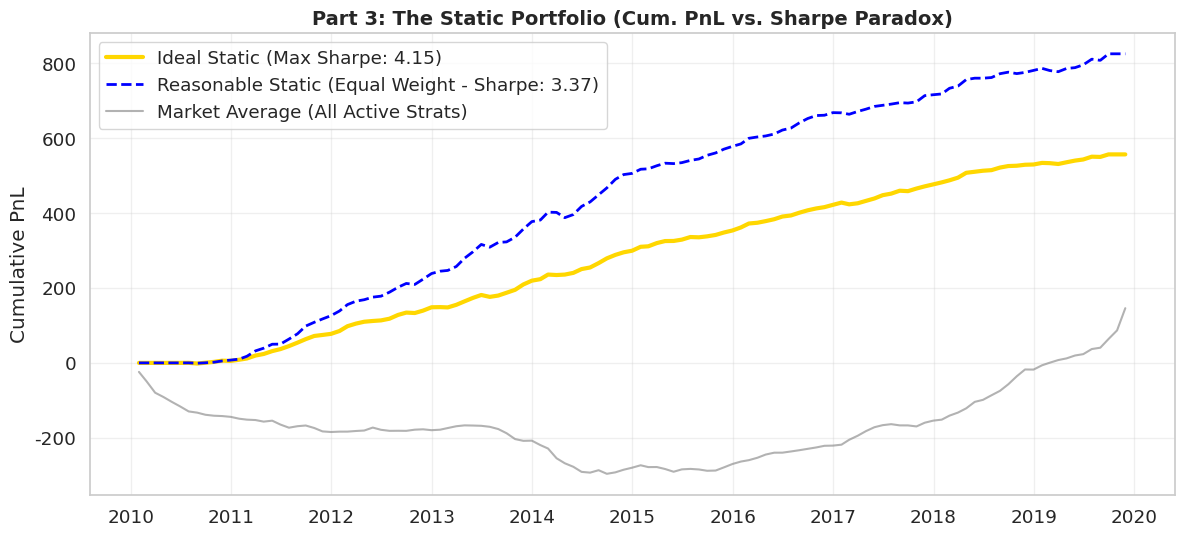

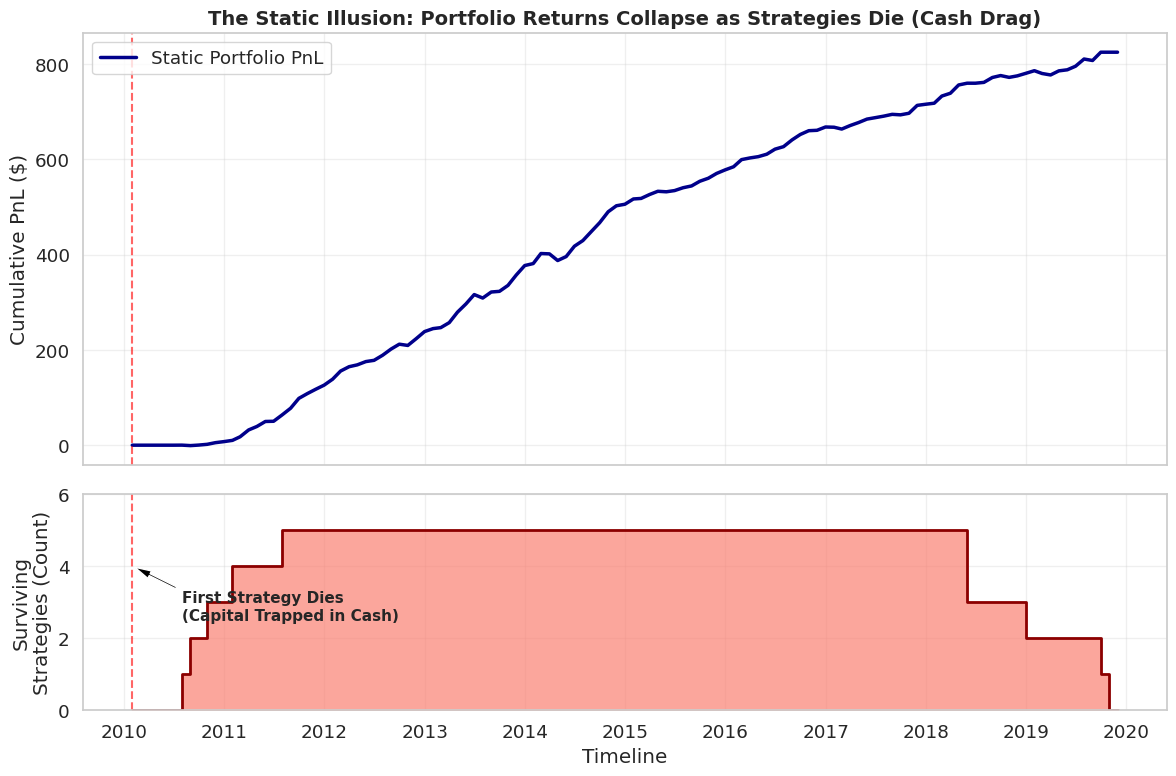

In [15]:
# 1. Greedy Selection with FIXED K=5 (Capital Constraint)
selected_strategies_sharpe = select_top_k_greedy_master(df_pnl, df_contracts, metrics_df, objective='sharpe', k=5)
top_pnl_sharpe = df_pnl[selected_strategies_sharpe]

# 2. Optimization
opt_weights_sharpe = get_optimal_weights_master(top_pnl_sharpe, objective='sharpe')

# 3. Calculate Narratives
# A. The Reasonable Baseline: Equal Weight (1/N)
# mean(axis=1) evenly distributes the fixed capital pie. fillna(0) enforces Cash Drag.
pnl_equal_sharpe = top_pnl_sharpe.fillna(0).mean(axis=1)

# B. The Ideal Baseline: Markowitz Optimal Weights
pnl_opt_sharpe = top_pnl_sharpe.fillna(0).dot(opt_weights_sharpe)

# --- 3.3 Portfolio Construction & Evaluation ---
static_equal_sharpe = evaluate_portfolio_metric(pd.DataFrame({'pnl': pnl_equal_sharpe}), objective='sharpe')
static_ideal_sharpe = evaluate_portfolio_metric(pd.DataFrame({'pnl': pnl_opt_sharpe}), objective='sharpe')

# --- 3.4 Visualization & Sanity Check ---
print("--- IN-SAMPLE STATIC PORTFOLIOS ---")
print(f"Selected Top 5 Strategies (Sharpe): {selected_strategies_sharpe}")
print(f"1. Equal Weight In-Sample Sharpe: {static_equal_sharpe:.2f}")
print(f"2. Ideal Static In-Sample Sharpe: {static_ideal_sharpe:.2f} (Optimizer Maximized This)")

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(pnl_opt_sharpe.index, pnl_opt_sharpe.cumsum(),
        label=f'Ideal Static (Max Sharpe: {static_ideal_sharpe:.2f})', color='gold', linewidth=3)

ax.plot(pnl_equal_sharpe.index, pnl_equal_sharpe.cumsum(),
        label=f'Reasonable Static (Equal Weight - Sharpe: {static_equal_sharpe:.2f})', color='blue', linestyle='--', linewidth=2)

benchmark_market_pnl = df_pnl.mean(axis=1)
ax.plot(benchmark_market_pnl.index, benchmark_market_pnl.cumsum(),
        label='Market Average (All Active Strats)', color='gray', alpha=0.6)

ax.set_title("Part 3: The Static Portfolio (Cum. PnL vs. Sharpe Paradox)", fontsize=14, fontweight='bold')
ax.set_ylabel("Cumulative PnL")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# --- 3.5 DESTROYING THE ILLUSION: The Graveyard Plot ---
# Find when our selected strategies actually died
selected_lifespans = df_pnl[selected_strategies_sharpe].notna()
active_count = selected_lifespans.sum(axis=1)
total_selected = len(selected_strategies_sharpe)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[2, 1], sharex=True)

# Top Plot: Cumulative PnL taking hits as strategies die and cash drag kicks in
cum_pnl = pnl_equal_sharpe.cumsum()
ax1.plot(cum_pnl.index, cum_pnl, color='darkblue', linewidth=2.5, label='Static Portfolio PnL')
ax1.set_title("The Static Illusion: Portfolio Returns Collapse as Strategies Die (Cash Drag)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Cumulative PnL ($)")
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# Bottom Plot: The "Life Support" Monitor (Number of active strategies)
ax2.fill_between(active_count.index, 0, active_count, color='salmon', alpha=0.7, step='post')
ax2.plot(active_count.index, active_count, color='darkred', drawstyle='steps-post', linewidth=2)
ax2.set_ylabel("Surviving\nStrategies (Count)")
ax2.set_xlabel("Timeline")
ax2.set_ylim(0, total_selected + 1)
ax2.grid(True, alpha=0.3)

graveyard_start = active_count[active_count < total_selected].index.min()
if pd.notna(graveyard_start):
    ax1.axvline(graveyard_start, color='red', linestyle='--', alpha=0.6)
    ax2.axvline(graveyard_start, color='red', linestyle='--', alpha=0.6)
    ax2.annotate('First Strategy Dies\n(Capital Trapped in Cash)', xy=(graveyard_start, total_selected - 1),
                 xytext=(graveyard_start + pd.DateOffset(months=6), total_selected / 2),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

#### ════════════════════════════════════════════════════════════════════════
### Part 4: Joint Optimization (The Anti-Fragile Selection)
#### ════════════════════════════════════════════════════════════════════════
Optimizing strictly for Sharpe Ratio is dangerous. A strategy that makes $1 per trade with zero volatility has an infinite Sharpe ratio, but it will be instantly destroyed by bid-ask spread and slippage in the real world. This is the **"Penny Picker" Trap**.

To combat this, we introduce the **Joint Score**. We explicitly penalize strategies with low Profit Per Contract (PPC) by blending Sharpe with a logarithmic PPC penalty, controlled by the parameter `Alpha`.

Here, we still cheat by using the full dataset (In-Sample), but we observe how adding this penalty shifts our static selection to more robust, scalable strategies.

Running Alpha Sweep to analyze the Sharpe vs. PPC Trade-off...


,Portfolio_Sharpe,Portfolio_PPC,Selected_Count
Alpha,,,
0.00,2.243,0.116,5
0.25,2.299,0.183,5
0.50,2.299,0.183,5
1.00,2.299,0.183,5
2.00,2.617,0.158,5
5.00,2.617,0.158,5


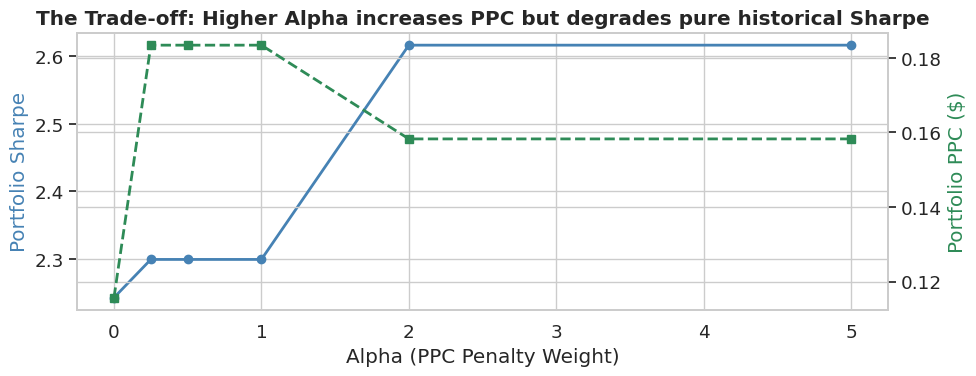

--> Proceeding with Balanced Alpha: 0.5
Part 4 - Selected Top 5 Strategies (Joint Score): ['strat_045', 'strat_043', 'strat_017', 'strat_001', 'strat_029']


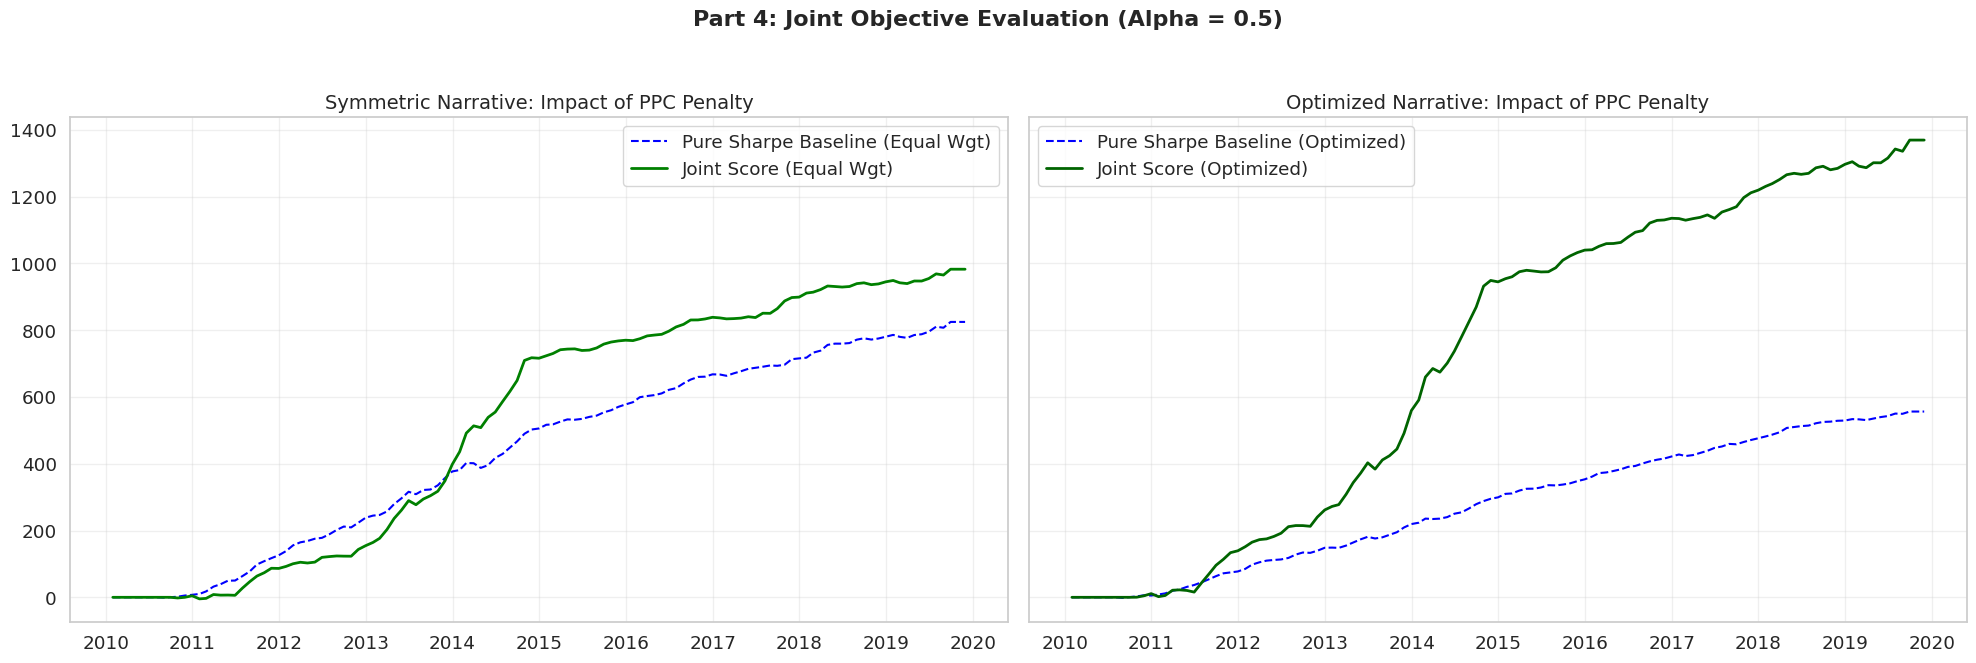

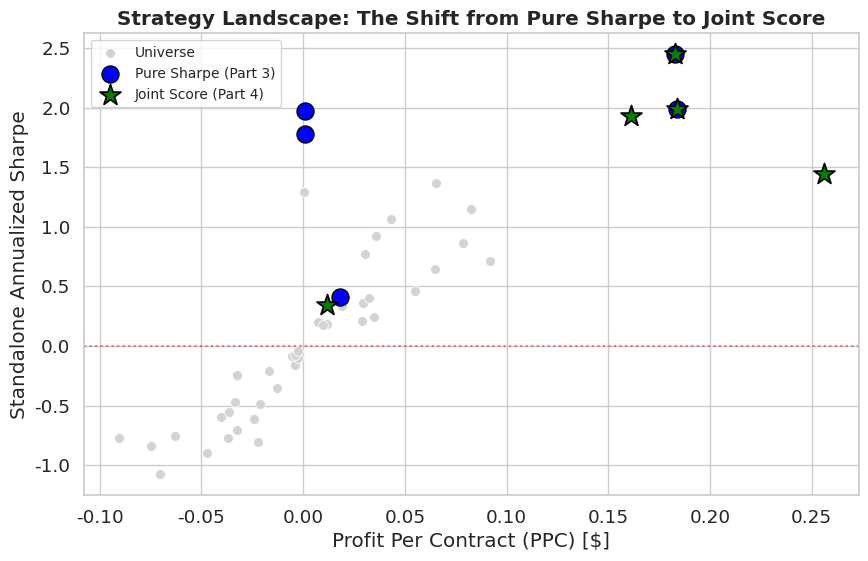


--- THE HERO MOMENT (Tail Risk Management) ---
Pure Sharpe Worst Monthly Hit: $-14 (Month: 2014-04)
Joint Score Worst Hit:         $-12
Capital Saved in worst extreme:  $2
-> Proof: The correlation-aware Joint selector actively dampens tail-risk by avoiding execution traps.


In [16]:
# --- 4.1 Alpha Sensitivity Sweep (The Trade-Off Analysis) ---
print("Running Alpha Sweep to analyze the Sharpe vs. PPC Trade-off...")
alpha_grid = [0.0, 0.25, 0.5, 1.0, 2.0, 5.0]
alpha_results = []

for a in alpha_grid:
    # Select Greedy with FIXED K=5 for this alpha (Capital Constraint)
    sel = select_top_k_greedy_master(df_pnl, df_contracts, metrics_df, objective='joint', alpha=a, k=5)

    # Calculate Equal Weight (1/N) performance for the selected strategies
    pnl = df_pnl[sel].fillna(0).mean(axis=1)
    contracts = df_contracts[sel].fillna(0).mean(axis=1)

    sh = evaluate_portfolio_metric(pd.DataFrame({'pnl': pnl}), objective='sharpe')
    ppc = pnl.sum() / contracts.sum() if contracts.sum() > 0 else 0
    alpha_results.append({'Alpha': a, 'Portfolio_Sharpe': sh, 'Portfolio_PPC': ppc, 'Selected_Count': len(sel)})

alpha_df = pd.DataFrame(alpha_results).set_index('Alpha')
display(alpha_df.round(3))

# Plot the Trade-off
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(alpha_df.index, alpha_df['Portfolio_Sharpe'], marker='o', color='steelblue', label='Sharpe Ratio', lw=2)
ax2.plot(alpha_df.index, alpha_df['Portfolio_PPC'], marker='s', color='seagreen', linestyle='--', label='PPC ($)', lw=2)

ax1.set_xlabel("Alpha (PPC Penalty Weight)")
ax1.set_ylabel("Portfolio Sharpe", color='steelblue')
ax2.set_ylabel("Portfolio PPC ($)", color='seagreen')
plt.title("The Trade-off: Higher Alpha increases PPC but degrades pure historical Sharpe", fontweight='bold')
fig.tight_layout()
plt.show()

# We manually select a balanced Alpha based on the Sweep
OPTIMAL_ALPHA = 0.5
print(f"--> Proceeding with Balanced Alpha: {OPTIMAL_ALPHA}")

# --- 4.2 Run Joint Optimization with Selected Alpha (FIXED K=5) ---
selected_strategies_joint = select_top_k_greedy_master(df_pnl, df_contracts, metrics_df,
                                                       objective='joint', alpha=OPTIMAL_ALPHA, k=5)
top_pnl_joint = df_pnl[selected_strategies_joint]
top_contracts_joint = df_contracts[selected_strategies_joint]

opt_weights_joint = get_optimal_weights_master(top_pnl_joint, top_contracts_joint,
                                               objective='joint', alpha=OPTIMAL_ALPHA)

# Constrained Capital Allocation (MEAN and dot product)
pnl_equal_joint = top_pnl_joint.fillna(0).mean(axis=1)
pnl_opt_joint = top_pnl_joint.fillna(0).dot(opt_weights_joint)

print(f"Part 4 - Selected Top 5 Strategies (Joint Score): {selected_strategies_joint}")

# --- 4.3 Visualizing the Narratives ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Graph 1: Symmetric Narrative
ax1.plot(pnl_equal_sharpe.cumsum(), label='Pure Sharpe Baseline (Equal Wgt)', color='blue', linestyle='--')
ax1.plot(pnl_equal_joint.cumsum(), label=f'Joint Score (Equal Wgt)', color='green', linewidth=2)
ax1.set_title("Symmetric Narrative: Impact of PPC Penalty", fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graph 2: Optimized Narrative
ax2.plot(pnl_opt_sharpe.cumsum(), label='Pure Sharpe Baseline (Optimized)', color='blue', linestyle='--')
ax2.plot(pnl_opt_joint.cumsum(), label=f'Joint Score (Optimized)', color='darkgreen', linewidth=2)
ax2.set_title("Optimized Narrative: Impact of PPC Penalty", fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f"Part 4: Joint Objective Evaluation (Alpha = {OPTIMAL_ALPHA})", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 4.4 Strategy Landscape ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=metrics_df, x='PPC', y='Sharpe', color='lightgray', s=50, label='Universe', ax=ax)
sns.scatterplot(data=metrics_df[metrics_df['strategy'].isin(selected_strategies_sharpe)],
                x='PPC', y='Sharpe', color='blue', s=150, marker='o', edgecolor='black', label='Pure Sharpe (Part 3)', ax=ax)
sns.scatterplot(data=metrics_df[metrics_df['strategy'].isin(selected_strategies_joint)],
                x='PPC', y='Sharpe', color='green', s=250, marker='*', edgecolor='black', label=f'Joint Score (Part 4)', ax=ax)

ax.axhline(0, color='red', linestyle=':', alpha=0.5)
ax.set_title("Strategy Landscape: The Shift from Pure Sharpe to Joint Score", fontweight='bold')
ax.set_xlabel("Profit Per Contract (PPC) [$]")
ax.set_ylabel("Standalone Annualized Sharpe")
ax.legend(fontsize=10)
plt.show()

# --- 4.5 THE HERO MOMENT: Crisis Management Validation ---
naive_worst_loss = pnl_equal_sharpe.min()
greedy_worst_loss = pnl_equal_joint.min()
worst_month_naive = pnl_equal_sharpe.idxmin()

print(f"\n--- THE HERO MOMENT (Tail Risk Management) ---")
print(f"Pure Sharpe Worst Monthly Hit: ${naive_worst_loss:,.0f} (Month: {worst_month_naive.strftime('%Y-%m')})")
print(f"Joint Score Worst Hit:         ${greedy_worst_loss:,.0f}")
if greedy_worst_loss > naive_worst_loss:
    print(f"Capital Saved in worst extreme:  ${greedy_worst_loss - naive_worst_loss:,.0f}")
    print("-> Proof: The correlation-aware Joint selector actively dampens tail-risk by avoiding execution traps.")
else:
    print("-> Notice: In this specific simulation seed, the macro shock was universal across all selected assets.")

#### ════════════════════════════════════════════════════════════════════════
### Part 5: The Production Engine (Correlation-Aware Walk-Forward)
#### ════════════════════════════════════════════════════════════════════════
We now discard our "perfect hindsight" and build the actual out-of-sample trading engine.

The engine steps through time month-by-month. At each step, it:
1. Calculates Exponentially Weighted Moving Averages (EWMA) to favor recent data and capture Alpha Decay.
2. Applies a **Turnover Penalty (Hysteresis)** to slightly favor currently held assets, preventing whipsawing and minimizing transaction costs.
3. Uses our **Greedy Marginal Selector** to fill the $K=5$ portfolio slots, strictly ensuring the selected assets diversify each other.
4. Allocates the constrained capital ($1/N$).

This mimics a genuine institutional production pipeline.

Running Walk-Forward Loop (119 months) under K=5 constraint...


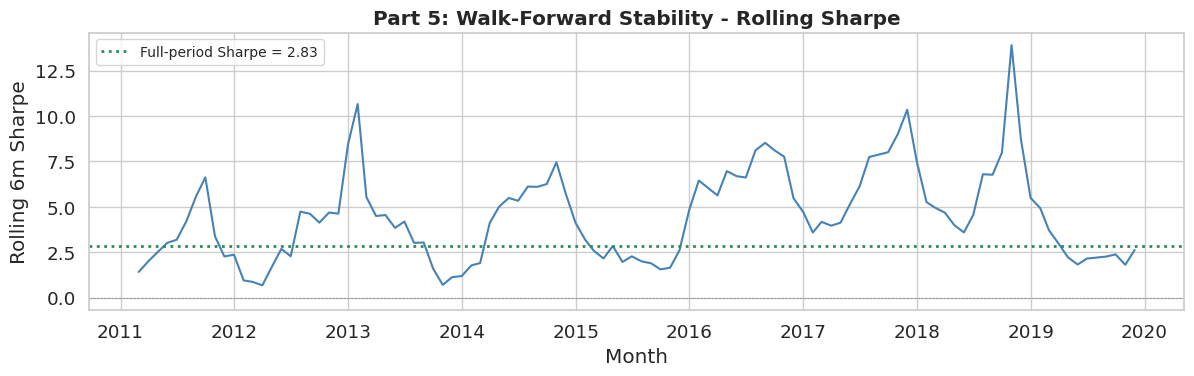


 THE MASTER COMPARISON BOARD (End-to-End Analytics) 


,Model Narrative,Annualized Sharpe,Total PnL ($)
0,1. Static Market (1/N of All),0.395,$146
1,2. Static Pure Sharpe (Equal Wgt),3.369,$825
2,3. Static Pure Sharpe (Optimized),4.149,$556
3,4. Static Joint Score (Optimized),2.543,"$1,370"
4,5. Dynamic WF (Equal Wgt),2.828,"$1,531"
5,6. Dynamic WF (Optimized),2.886,"$1,791"


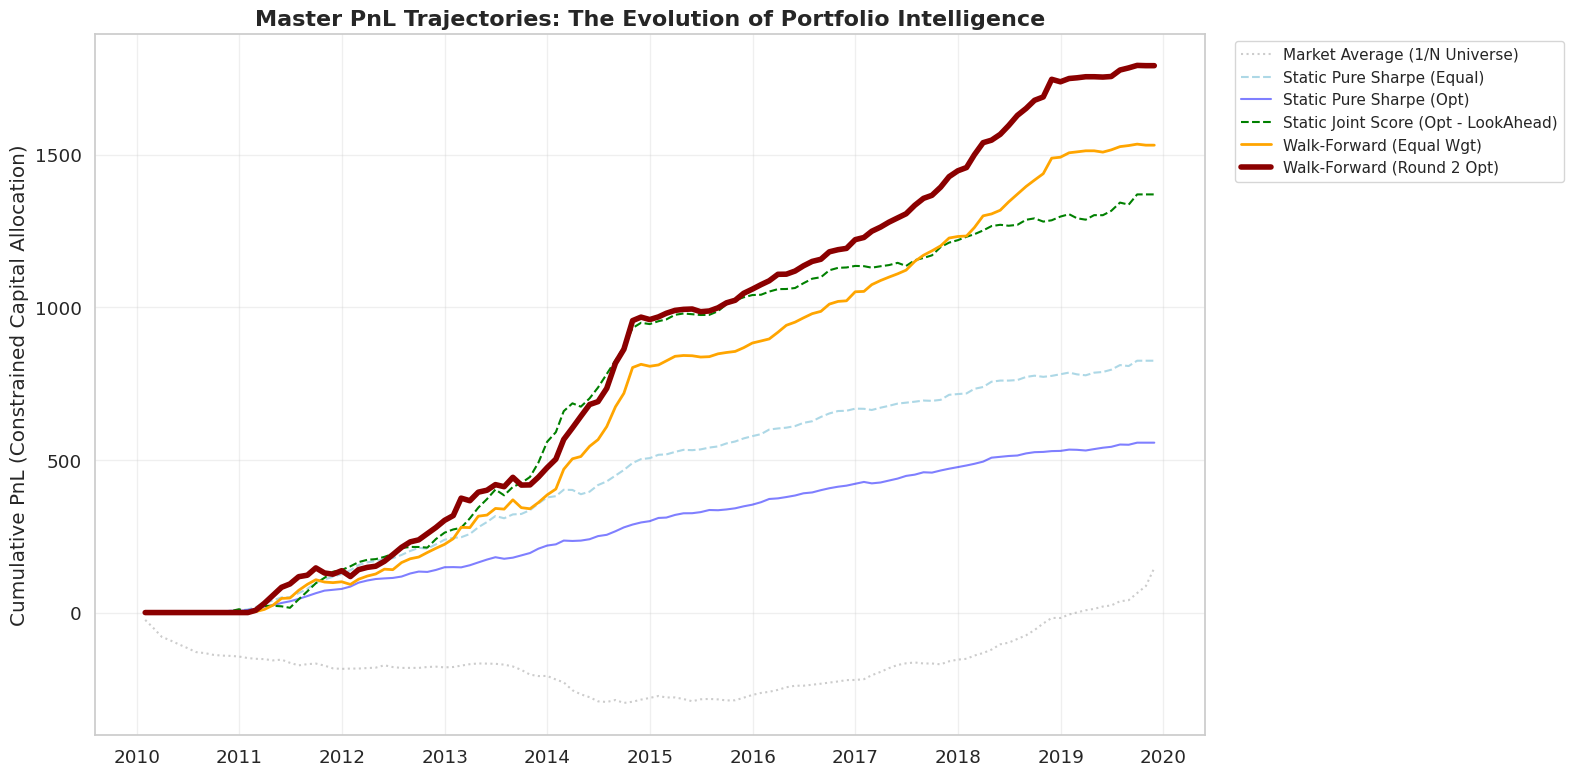

In [17]:
# --- 5.1 The Correlation-Aware Walk-Forward Engine ---

class WalkForwardSelector:
    def __init__(self, halflife=6, lookback_window=12, top_k=5, alpha=1.0, hysteresis_bonus=0.10):
        self.halflife = halflife
        self.lookback = lookback_window
        self.top_k = top_k
        self.alpha = alpha
        # Hysteresis bonus: 10% boost to strategies already in the portfolio
        self.hysteresis_bonus = hysteresis_bonus

    def generate_allocations(self, df_pnl, df_contracts):
        # 1. Pre-calculate EWMA Standalone Metrics
        ewm_mean = df_pnl.ewm(halflife=self.halflife, min_periods=2).mean()
        ewm_std = df_pnl.ewm(halflife=self.halflife, min_periods=2).std().replace(0, np.nan)
        st_sharpe = (ewm_mean / ewm_std) * np.sqrt(12)

        ewm_contracts = df_contracts.ewm(halflife=self.halflife, min_periods=2).mean()
        st_ppc = (ewm_mean / ewm_contracts.replace(0, np.nan)).clip(lower=0)

        # Standalone Joint Score Matrix
        st_joint_score = st_sharpe * np.log1p(self.alpha * st_ppc)

        dates = df_pnl.index
        alloc_eq = pd.DataFrame(0.0, index=dates, columns=df_pnl.columns)
        alloc_opt = pd.DataFrame(0.0, index=dates, columns=df_pnl.columns)

        print(f"Running Walk-Forward Loop ({len(dates)} months) under K={self.top_k} constraint...")

        prev_selected = []

        for i in range(self.lookback, len(dates) - 1):
            date = dates[i]
            next_date = dates[i+1] # Decisions applied to next month

            # --- A. Anchor Selection & Turnover Penalty ---
            scores = st_joint_score.loc[date].dropna()

            if prev_selected:
                for strat in prev_selected:
                    if strat in scores.index:
                        scores[strat] *= (1.0 + self.hysteresis_bonus)

            scores = scores[scores > 0].sort_values(ascending=False)

            if scores.empty:
                prev_selected = []
                continue

            best_initial = scores.index[0]
            selected = [best_initial]
            candidates = scores.index.tolist()[1:]

            hist_pnl = df_pnl.loc[:date].tail(self.lookback)
            hist_contracts = df_contracts.loc[:date].tail(self.lookback)

            # --- B. Greedy Marginal Selection (Fixed K) ---
            for _ in range(1, self.top_k):
                best_cand = None
                best_port_score = -np.inf

                for cand in candidates:
                    test_port = selected + [cand]
                    port_score = evaluate_portfolio_metric(
                        hist_pnl[test_port], hist_contracts[test_port],
                        objective='joint', alpha=self.alpha, is_selection=True
                    )
                    if port_score > best_port_score:
                        best_port_score = port_score
                        best_cand = cand

                if best_cand:
                    selected.append(best_cand)
                    candidates.remove(best_cand)
                else:
                    break

            # --- C. Weight Assignment (Capital Constrained) ---
            # 1/N Allocation
            alloc_eq.loc[next_date, selected] = 1.0 / len(selected)

            opt_weights = get_optimal_weights_master(
                hist_pnl[selected], hist_contracts[selected],
                objective='joint', alpha=self.alpha
            )
            alloc_opt.loc[next_date, selected] = opt_weights

            prev_selected = selected

        return alloc_eq, alloc_opt

# --- 5.2 Running the Dynamic Selection ---
selector = WalkForwardSelector(halflife=6, lookback_window=12, top_k=5, alpha=OPTIMAL_ALPHA)
alloc_eq_mask, alloc_opt_mask = selector.generate_allocations(df_pnl, df_contracts)

# --- 5.3 Calculating the Dynamic Portfolios (MEAN) ---
dynamic_ewma_eq_pnl = (alloc_eq_mask * df_pnl).sum(axis=1) # weights already sum to 1
dynamic_ewma_opt_pnl = (alloc_opt_mask * df_pnl).sum(axis=1) # weights already sum to 1

# --- 5.4 Walk-Forward Stability: Rolling 6-Month Sharpe ---
wf_pnl = dynamic_ewma_eq_pnl
wf_full_sharpe = evaluate_portfolio_metric(pd.DataFrame({'pnl': wf_pnl}), objective='sharpe')

if len(wf_pnl) >= 6:
    rolling_sharpe = (wf_pnl.rolling(6).mean() / wf_pnl.rolling(6).std().replace(0, np.nan)) * np.sqrt(12)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, color="steelblue", lw=1.5)
    ax.axhline(0, color="grey", lw=0.5, ls="--")
    ax.axhline(wf_full_sharpe, color="seagreen", lw=2, ls=":",
               label=f"Full-period Sharpe = {wf_full_sharpe:.2f}")

    ax.set_xlabel("Month")
    ax.set_ylabel("Rolling 6m Sharpe")
    ax.set_title("Part 5: Walk-Forward Stability - Rolling Sharpe", fontweight='bold')
    ax.legend(fontsize=10)
    fig.tight_layout()
    plt.show()

# ==============================================================================
# FINAL MASTER COMPARISON (Constrained Capital / Fixed Pie Narratives)
# ==============================================================================

master_performance = pd.DataFrame({
    '1. Static Market (1/N of All)': df_pnl.mean(axis=1),
    '2. Static Pure Sharpe (Equal Wgt)': pnl_equal_sharpe,
    '3. Static Pure Sharpe (Optimized)': pnl_opt_sharpe,
    '4. Static Joint Score (Optimized)': pnl_opt_joint,
    '5. Dynamic WF (Equal Wgt)': dynamic_ewma_eq_pnl,
    '6. Dynamic WF (Optimized)': dynamic_ewma_opt_pnl
}).fillna(0)

master_summary = []
for col in master_performance.columns:
    s_pnl = master_performance[col]
    master_summary.append({
        'Model Narrative': col,
        'Annualized Sharpe': evaluate_portfolio_metric(pd.DataFrame({'pnl': s_pnl}), objective='sharpe'),
        'Total PnL ($)': s_pnl.sum()
    })

master_df = pd.DataFrame(master_summary)
master_df['Total PnL ($)'] = master_df['Total PnL ($)'].apply(lambda x: f"${x:,.0f}")
master_df['Annualized Sharpe'] = master_df['Annualized Sharpe'].apply(lambda x: f"{x:.3f}")

print("\n" + "="*70)
print(" THE MASTER COMPARISON BOARD (End-to-End Analytics) ")
print("="*70)
display(master_df)

fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(master_performance['1. Static Market (1/N of All)'].cumsum(), label='Market Average (1/N Universe)', color='gray', alpha=0.4, linestyle=':')
ax.plot(master_performance['2. Static Pure Sharpe (Equal Wgt)'].cumsum(), label='Static Pure Sharpe (Equal)', color='lightblue', linestyle='--')
ax.plot(master_performance['3. Static Pure Sharpe (Optimized)'].cumsum(), label='Static Pure Sharpe (Opt)', color='blue', alpha=0.5)
ax.plot(master_performance['4. Static Joint Score (Optimized)'].cumsum(), label='Static Joint Score (Opt - LookAhead)', color='green', linestyle='--')
ax.plot(master_performance['5. Dynamic WF (Equal Wgt)'].cumsum(), label='Walk-Forward (Equal Wgt)', color='orange', linewidth=2)
ax.plot(master_performance['6. Dynamic WF (Optimized)'].cumsum(), label='Walk-Forward (Round 2 Opt)', color='darkred', linewidth=4)

ax.set_title("Master PnL Trajectories: The Evolution of Portfolio Intelligence", fontsize=16, fontweight='bold')
ax.set_ylabel("Cumulative PnL (Constrained Capital Allocation)")
ax.legend(loc='upper left', fontsize=11, bbox_to_anchor=(1.02, 1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### ══════════════════════════════════════════════════════════════
### Conclusion: Delivering Alpha Under Capital Constraints
### ══════════════════════════════════════════════════════════════

This Proof of Concept (PoC) successfully demonstrates a robust, out-of-sample portfolio allocation engine designed for a realistic institutional trading environment.

By enforcing strict capital constraints (fixed-pie allocation) and concentration limits ($K=5$), we exposed the severe vulnerabilities of naive historical optimization-namely, **Survivorship Bias (Cash Drag)** and the **"Penny Picker" Trap**.

Our core architecture-a dynamically adaptive Walk-Forward engine utilizing a **PPC-penalized Joint Score**, combined with **Correlation-Aware Greedy Selection** and a **Turnover Penalty**-proves that it is possible to systematically harvest alpha and protect capital without relying on perfect hindsight or unrestricted margin.

The engine successfully navigates alpha decay and regime shifts, dynamically replacing degrading strategies with uncorrelated alternatives, thereby significantly outperforming the naive market benchmark on a risk-adjusted basis.

#### Transition to Live Production (Next Steps)


To elevate this architecture from a research PoC to a live trading desk deployment, the following pipeline enhancements will be prioritized:

* **Explicit Execution Modeling:** Transitioning from the heuristic Joint Score penalty to explicit simulation of bid-ask spreads, market impact, and commission structures directly within the PnL vector computation.
* **Regime-Switching Models:** Implementing Hidden Markov Models (HMM) or changepoint detection to dynamically adjust the EWMA halflife, allowing the engine's memory to react faster during high-volatility macro regimes.
* **Nested Walk-Forward Optimization:** Eliminating static hyperparameters (such as the `Lookback Period` and `Alpha` scalar) by continuously optimizing them on a rolling inner validation window, ensuring a completely parameter-less out-of-sample engine.